# Лабораторная №4. Численное интегрирование
## Задание 1.
Написать программу, которая вычисляет интеграл с заданной точностью
с помощью указанных составных квадратурных формул с автоматическим выбором шага
по правилу Рунге. Для каждой КФ вывести приближенное значения интеграла,
уточненное значение, а также величину шага. Сравнить приближенное значение интеграла
с точным, вычисленным аналитически.  
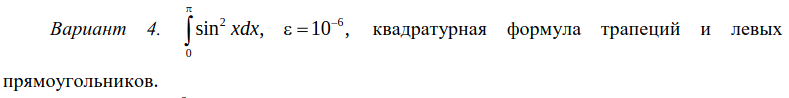  
Точное значение = pi / 2  
Составная формула левых прямоугольников:  
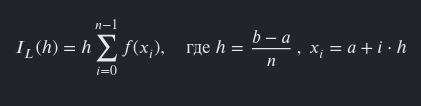  
Составная формула трапеций:  
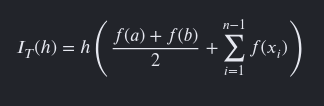  
Оценка погрешности:  
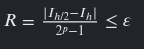  
Уточненное значение:  
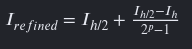  
Порядок точности: p = 1 (для прямоугольников), p = 2 (для трапеций).

In [2]:
import numpy as np
import pandas as pd

pi = np.pi
a, b = 0, pi
eps = 1e-6
deltaL = 1
deltaT = 1
nL = 1
nT = 1
pL = 1
pT = 2
IEX = pi / 2

def func1(x):
    return np.sin(x) ** 2

sum = 0
h = (b - a) / nL
for i in range(nL):
    xi = a + h * i
    sum += func1(xi)
IL = h * sum

sum = 0
h = (b - a) / nT
for i in range(nT):
    xi = a + h * i
    sum += func1(xi)
IT = h * ((func1(a) + func1(b)) / 2 + sum)

while deltaL > eps:
    sum = 0
    nL *= 2
    h = (b - a) / nL
    for i in range(nL):
        xi = a + h * i
        sum += func1(xi)
    IL2 = h * sum
    deltaL = np.abs(IL2 - IL) / (2 ** pL - 1)
    ILR = IL2 + (IL2 - IL) / (2 ** pL - 1)
    IL = IL2
    
while deltaT > eps:
    sum = 0
    nT *= 2
    h = (b - a) / nT
    for i in range(1, nT):
        xi = a + h * i
        sum += func1(xi)
    IT2 = h * ((func1(a) + func1(b)) / 2 + sum)
    deltaT = np.abs(IT2 - IT) / (2 ** pT - 1)
    ITR = IT2 + (IT2 - IT) / (2 ** pT - 1)
    IT = IT2


df = pd.DataFrame(columns=['n', 'h', 'I', 'I_refined', 'abs_error'])
df.loc[0] = [nL, (b - a) / nL, IL2, ILR, np.abs(ILR - IEX)]
df.loc[1] = [nT, (b - a) / nT, IT2, ITR, np.abs(ITR - IEX)]
display(df)

,n,h,I,I_refined,abs_error
0,4.0,0.785398,1.570796,1.570796,0.0
1,4.0,0.785398,1.570796,1.570796,0.0


## Задание 2
Используя частные случаи КФ НАСТ, найти приближенное значение
интеграла с точностью 10–4. При необходимости предварительно преобразовать исходный
интеграл (например, с помощью замены переменной). Корни ортогональных многочленов
можно находить любым способом, в т.ч. используя готовые таблицы или библиотеки.  
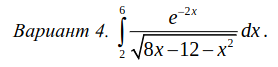  
После преобразования получим формулу Гаусса-Чебышева 1-го рода  
p(x) =  1 / sqrt(1 - x^2)  
f(x) = e ^ (-4(x + 2))  

In [4]:
delta = 1
eps = 1e-4
n = 0
IGCH_prev = 0

def func2(x):
    return np.exp(-4 * (x + 2))

while delta > eps:
    n += 1
    A = np.full(shape=(n), fill_value=pi/n)
    x = [np.cos((2*i-1)/(2*n)*pi) for i in range(1, n + 1)]
    sum = 0
    for xi in x:
        sum += func2(xi)
    IGCH = pi / n * sum
    delta = IGCH - IGCH_prev
    IGCH_prev = IGCH 
df = pd.DataFrame(columns=['n', 'I'])
df.loc[0] = [n, IGCH]
display(df)

,n,I
0,5.0,0.01191
